In [1]:
import random # библиотека функций для генерации случайных значений
# Сторонние библиотеки
import numpy as np # библиотека функций для работы с матрицами
""" ---Раздел описаний--- """
""" --Описание класса Network--"""
class Network(object): # используется для описания нейронной сети
    def __init__(self, sizes): # конструктор класса
# self – указатель на объект класса
# sizes – список размеров слоев нейронной сети
        self.num_layers = len(sizes) # задаем количество слоев нейронной сети
        self.sizes = sizes # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]] # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])] # задаем случайные начальные веса связей
    def sigmoid(self,z): # определение сигмоидальной функции активации 
        return 1.0/(1.0+np.exp(-z))
    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a)+b)
        return a
    def SGD( # Стохастический градиентный спуск
        self # указатель на объект класса
        , training_data # обучающая выборка
        , epochs # количество эпох обучения
        , mini_batch_size # размер подвыборки
        , eta # скорость обучения
        , test_data # тестирующая выборка
        ):
        test_data = list(test_data) # создаем список объектов тестирующей выборки
        n_test = len(test_data) # вычисляем длину тестирующей выборки
        training_data = list(training_data) # создаем список объектов обучающей выборки
        n = len(training_data) # вычисляем размер обучающей выборки
        for j in range(epochs): # цикл по эпохам
            random.shuffle(training_data) # перемешиваем элементы обучающей выборки
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)] # создаем подвыборки
            for mini_batch in mini_batches: # цикл по подвыборкам
              #print(len(mini_batch[0][0]))
              self.update_mini_batch(mini_batch, eta) # один шаг градиентного спуска
            print ("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test)) # смотрим прогресс в обучении
    def update_mini_batch( # Шаг градиентного спуска
        self # указатель на объект класса
        , mini_batch # подвыборка
        , eta # скорость обучения
        ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y) # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)] # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)] # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nabla_w)] # обновляем все веса w нейронной сети
        self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nabla_b)] # обновляем все смещения b нейронной сети
    def backprop( # Алгоритм обратного распространения
        self # указатель на объект класса  
      ,x # вектор входных сигналов , 
      ,y # ожидаемый вектор выходных сигналов
      ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [x] # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = [] # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b # считаем активационные потенциалы текущего слоя
            zs.append(z) # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(z) # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation) # добавляем элемент (выходные сигналы слоя) в конец списка
  # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1]) # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose()) # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
          z = zs[-l] # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
          sp = self.sigmoid_prime(z) # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
          delta = np.dot(self.weights[-l+1].transpose(), delta) * sp # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
          nabla_b[-l] = delta # градиент dC/db для l-го слоя (BP3)
          nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())# градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)
    def evaluate(self, test_data): # Оценка прогресса в обучении
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)
    def cost_derivative(self, output_activations, y): # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
      return (output_activations-y)
    def sigmoid_prime(self,z):# Производная сигмоидальной функции
      return self.sigmoid(z)*(1-self.sigmoid(z))
# """ --Конец описания класса Network--"""
# """ --- Конец раздела описаний--- """
# """ ---Тело программы--- """ 
# net = Network([2, 3, 1]) # создаем нейронную сеть из трех слоев 
# """---Конец тела программы--- """
# """ Вывод результата на экран: """ 
# print('Сеть net:') 
# print('Количетво слоев:', net.num_layers) 
# for i in range(net.num_layers): 
#     print('Количество нейронов в слое', i,':',net.sizes[i]) 
# for i in range(net.num_layers-1): 
#     print('W_',i+1,':') 
#     print(np.round(net.weights[i],2)) 
#     print('b_',i+1,':') 
#     print(np.round(net.biases[i],2))
    

In [2]:
import gzip # библиотека для сжатия и распаковки файлов gzip и gunzip.
import pickle # библиотека для сохранения и загрузки сложных объектов Python.
import numpy as np # библиотека для работы с матрицами
# def load_data():
#   #f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   f = gzip.open('/content/drive/MyDrive/Colab Notebooks/mnist.npz~1/mnist.npz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   training_data, test_data = pickle.load(f, encoding='latin1') # загружам таблицы из файла
#   f.close() # закрываем файл
#   return (training_data, test_data)

def load_data(path,n):
    with np.load(path) as f:
        (x_train, y_train) = f['x_train'][:n], f['y_train'][:n]
        (x_test, y_test) = f['x_test'], f['y_test']
    return ((x_train, y_train), (x_test, y_test))

(x_train, y_train), (x_test, y_test) = load_data('mnist.npz',60000)

X_train=[]
thresholdedData=[]
for i in range(len(x_train)):
    row=np.reshape(x_train[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_train.append(thresholdedData)

X_test=[]
thresholdedData=[]
for i in range(len(x_test)):
    row=np.reshape(x_test[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_test.append(thresholdedData)

In [3]:
def load_data_wrapper(n, load = 'mnist.npz'):
    #tr_d, te_d = load_data(path) # инициализация наборов данных в формате MNIST
    (x_train, y_train), (x_test, y_test) = load_data(load, n)
    training_inputs = [((np.reshape(x, (784,1)) > 0) * 1.0) for x in (x_train)] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    training_results = [vectorized_result(y) for y in (y_train)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    training_data =list (zip(training_inputs, training_results)) # формируем набор обучающих данных из пар (x, y)
   # validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
   # validation_data = zip(validation_inputs, va_d[1]) # формируем набор данных проверки из пар (x, y)
    test_inputs = [((np.reshape(x, (784,1)) > 0) * 1.0) for x in (x_test)] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    #test_results = [vectorized_result(y) for y in (y_test)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    test_data = list(zip(test_inputs,y_test)) # формируем набор тестовых данных из пар (x, y)
    return (training_data, test_data)


# def load_data():

#  f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в
# двоичном режиме
#  training_data, validation_data, test_data = pickle.load(f,
# encoding='latin1') # загружам таблицы из файла
#  f.close() # закрываем файл
#  return (training_data, validation_data, test_data)


#     def load_data_wrapper():

#  tr_d, va_d, te_d = load_data() # инициализация наборов данных в формате
# MNIST
#  training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  training_results = [vectorized_result(y) for y in tr_d[1]] #
# представление цифр от 0 до 9 в виде массивов размера 10 на 1
#  training_data = zip(training_inputs, training_results) # формируем
# набор обучающих данных из пар (x, y)
#  validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  validation_data = zip(validation_inputs, va_d[1]) # формируем набор
# данных проверки из пар (x, y)
#  test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  test_data = zip(test_inputs, te_d[1]) # формируем набор тестовых данных
# из пар (x, y)
#  return (training_data, validation_data, test_data)

In [4]:
def vectorized_result(j):
  e = np.zeros((10, 1))
  e[j] = 1.0
  return e

(array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]

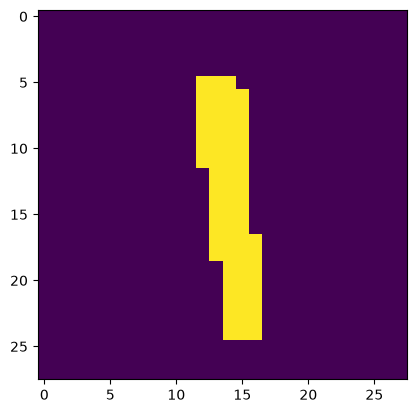

In [5]:
import matplotlib.pyplot as plt
training_data,test_data = load_data_wrapper(50000)
print(training_data[8])
lll8=np.reshape(training_data[8][0],(28,28))
plt.imshow(lll8)
plt.show()

Создайте нейронную сеть для распознавания рукописных цифр:


In [6]:
net = Network([784, 30, 10])
""" Вывод результата на экран: """ 
print('Сеть net:') 
print('Количетво слоев:', net.num_layers) 
for i in range(net.num_layers): 
    print('Количество нейронов в слое', i,':',net.sizes[i]) 
for i in range(net.num_layers-1): 
    print('W_',i+1,':') 
    print(np.round(net.weights[i],2)) 
    print('b_',i+1,':') 
    print(np.round(net.biases[i],2))
    

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 30
Количество нейронов в слое 2 : 10
W_ 1 :
[[-0.95 -1.5  -0.68 ...  0.79  0.17  1.03]
 [ 1.35  0.98  0.94 ...  1.26  1.21 -0.73]
 [-0.62  0.41 -1.48 ...  0.54 -0.69 -1.81]
 ...
 [-2.34  0.65 -0.1  ... -0.4   1.42  1.87]
 [-0.3  -0.14  0.08 ...  1.11  1.87  1.45]
 [ 0.86  0.54  1.23 ...  0.97 -1.39 -1.56]]
b_ 1 :
[[-0.78]
 [-0.66]
 [ 0.3 ]
 [-0.19]
 [ 1.33]
 [ 0.32]
 [-0.82]
 [ 0.04]
 [-1.38]
 [-0.44]
 [ 1.06]
 [ 0.37]
 [ 0.85]
 [ 1.63]
 [-0.9 ]
 [-0.54]
 [ 0.18]
 [ 1.47]
 [-0.33]
 [-0.34]
 [-1.29]
 [ 0.35]
 [ 0.06]
 [-1.43]
 [-1.39]
 [-1.5 ]
 [ 0.44]
 [-0.62]
 [-0.42]
 [ 1.26]]
W_ 2 :
[[-0.92  0.3   0.73  0.39 -0.2  -0.02  1.15  1.34 -0.26  1.59 -0.74 -1.85
  -0.23  0.61 -2.14  0.86  1.36  0.33 -0.21  0.57 -0.36  1.42 -1.48 -0.45
   0.29 -0.97 -0.43 -0.7  -0.24  1.22]
 [ 0.86 -0.19 -2.08  0.04 -1.83  1.22  1.67  0.69  0.14  0.33  0.53 -0.43
  -1.3   0.72  0.3   1.65  0.03  0.44 -1.36  1.53 -

Запустите процедуру обучения созданной нейронной сети, включающую 30 эпох:

In [7]:
import os

MODEL_FILE = 'emnist_model.npz'

if os.path.exists(MODEL_FILE):
    data = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data['weights'])
    net.biases = list(data['biases'])

else:

    net.SGD(
        training_data,
        30,
        10,
        3.0,
        test_data=test_data
    )

    np.savez(
        MODEL_FILE,
        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object)
    )

In [8]:
# net.SGD(training_data, 30, 10, 3.0, test_data=test_data)
#  , training_data # обучающая выборка
#         , epochs # количество эпох обучения
#         , mini_batch_size # размер подвыборки
#         , eta # скорость обучения
#         , test_data # тестирующая выборка

In [9]:
from sklearn.metrics import confusion_matrix, classification_report


# Forward propagate input to a network output
def forward_propagate(net, row):
    inputs = row
    for i in range(net.num_layers-1):
        new_inputs = []
        for b, w in zip(net.biases[i], net.weights[i]):
            activation = np.dot(w,inputs)+b
            out = net.sigmoid(activation)
            new_inputs.append(out)
        inputs = new_inputs
    return new_inputs
		  


# Make a prediction with a network
def predict(net, row):
    outputs = forward_propagate(net, row)
    return outputs.index(max(outputs))

i=-1
X_train=[]
thresholdedData=[]

for i in range(len(x_train)):
    row=np.reshape(x_train[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_train.extend(thresholdedData)


for i in range(len(X_train)):
    prediction = predict(net,X_train[i])
    if (i==0):
      predictTrain = np.array([[prediction]])
    else:
      predictTrain =np.append(predictTrain,[[prediction]],axis=0)

In [10]:
print(confusion_matrix(y_train, predictTrain))
print(classification_report(y_train, predictTrain))

[[5774    5   10   15    5   22   18    4   63    7]
 [   1 6593   29   26   12   13    8   13   38    9]
 [  29   11 5670   32   48   10   22   50   66   20]
 [  35   26   75 5687    6   99   14   58  105   26]
 [  10   15   22    2 5632    2   33   14   19   93]
 [  33   15   26   83   17 5101   51   10   67   18]
 [  26    5    8    3   24   47 5754    1   49    1]
 [  11   15   44   16   32    5    3 6066   16   57]
 [  26   41   30   51   21   41   34   18 5569   20]
 [  34   14    7   91   86   40    4   66   60 5547]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5923
           1       0.98      0.98      0.98      6742
           2       0.96      0.95      0.95      5958
           3       0.95      0.93      0.94      6131
           4       0.96      0.96      0.96      5842
           5       0.95      0.94      0.94      5421
           6       0.97      0.97      0.97      5918
           7       0.96      0.97   

In [11]:
class Network(object): # используется для описания нейронной сети
    def __init__(self, sizes, alpha=4): # конструктор класса
# self – указатель на объект класса
# sizes – список размеров слоев нейронной сети
        self.alpha = alpha
        self.num_layers = len(sizes) # задаем количество слоев нейронной сети
        self.sizes = sizes # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]] # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])] # задаем случайные начальные веса связей
    def sigmoid(self, z):
        T = 0
        return 1.0 / (1.0 + np.exp(-self.alpha * (z - T)))
    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a)+b)
        return a
    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        n = len(training_data)

        train_loss_history = []
        valid_loss_history = []

        for j in range(epochs):

            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            train_loss = self.total_loss(training_data)
            train_loss_history.append(train_loss)

            if test_data is not None:
                valid_loss = self.total_loss(test_data)
                valid_loss_history.append(valid_loss)

                accuracy = self.evaluate(test_data)

                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}, "
                    f"validation loss = {valid_loss:.6f}, "
                    f"accuracy = {accuracy}/{len(test_data)}"
                )

            else:
                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}"
                )

        return train_loss_history, valid_loss_history
    def update_mini_batch( # Шаг градиентного спуска
        self # указатель на объект класса
        , mini_batch # подвыборка
        , eta # скорость обучения
        ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y) # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)] # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)] # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nabla_w)] # обновляем все веса w нейронной сети
        self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nabla_b)] # обновляем все смещения b нейронной сети
    def backprop( # Алгоритм обратного распространения
        self # указатель на объект класса
      ,x # вектор входных сигналов ,
      ,y # ожидаемый вектор выходных сигналов
      ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [x] # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = [] # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b # считаем активационные потенциалы текущего слоя
            zs.append(z) # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(z) # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation) # добавляем элемент (выходные сигналы слоя) в конец списка
  # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1]) # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose()) # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
          z = zs[-l] # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
          sp = self.sigmoid_prime(z) # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
          delta = np.dot(self.weights[-l+1].transpose(), delta) * sp # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
          nabla_b[-l] = delta # градиент dC/db для l-го слоя (BP3)
          nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())# градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)
    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), np.argmax(y))
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)
    def cost_derivative(self, output_activations, y): # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
      return (output_activations-y)
    def sigmoid_prime(self,z):# Производная сигмоидальной функции
      return self.alpha * self.sigmoid(z) * (1 - self.sigmoid(z))
    def total_loss(self, data):
        total = 0.0

        for x, y in data:
            output = self.feedforward(x)

            # MSE
            total += np.sum((output - y) ** 2) / 2

        return total / len(data)

In [19]:
data = np.load('emnist_k_to_t_one.npz')

X_train = data['X_train']
y_train_onehot = data['y_train']

X_test = data['X_test']
y_test_onehot = data['y_test']


y_train = np.argmax(y_train_onehot, axis=1)
y_test = np.argmax(y_test_onehot, axis=1)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(
    X_train,
    y_train_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

y_train = np.argmax(y_train_onehot, axis=1)
y_val = np.argmax(y_val_onehot, axis=1)


X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0


training_inputs = [
    np.reshape(x, (784, 1))
    for x in X_train
]

training_results = [
    np.reshape(y, (10, 1))
    for y in y_train_onehot
]

training_data = list(
    zip(training_inputs, training_results)
)

validation_inputs = [
    np.reshape(x, (784, 1))
    for x in X_val
]

validation_results = [
    np.reshape(y, (10, 1))
    for y in y_val_onehot
]

validation_data = list(
    zip(validation_inputs, validation_results)
)


test_inputs = [
    np.reshape(x, (784, 1))
    for x in X_test
]

test_data = list(
    zip(test_inputs, y_test)
)


net = Network([784, 70, 10])

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])


MODEL_FILE = 'litters_model_alpha4.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[145   3   4   0   0   4   0   0   4   0]
 [  4 156   0   0   0   0   0   0   0   0]
 [  0   0 152   0   0   6   0   2   0   0]
 [ 10   0  35   9   0  50   0  44  12   0]
 [ 15   0   9   8   0  20   0  18  90   0]
 [  4   3   2   0   0 139   0   3   8   1]
 [ 39   8   9   5   1  32   0   1  64   1]
 [  7   1   0   0   0   6   0 143   3   0]
 [  7   0   1   1   0   1   0   0 150   0]
 [ 31  46  14   3   1  20   2  13  29   1]]

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.91      0.69       160
           1       0.72      0.97      0.83       160
           2       0.67      0.95      0.79       160
           3       0.35      0.06      0.10       160
           4       0.00      0.00      0.00       160
           5       0.50      0.87      0.63       160
           6   

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

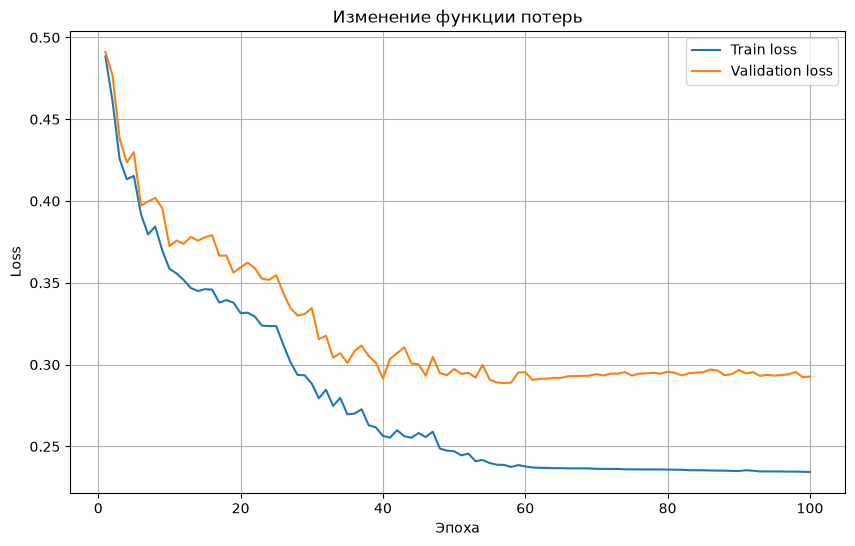

In [13]:
import matplotlib.pyplot as plt

def graphic():
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        train_loss,
        label='Train loss'
    )

    plt.plot(
        epochs,
        valid_loss,
        label='Validation loss'
    )

    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title('Изменение функции потерь')
    plt.legend()
    plt.grid()
    plt.show()

graphic()


Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

In [14]:
net = Network([784, 70, 10], alpha=3.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])


MODEL_FILE = 'litters_model_alpha35.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10
Epoch 1: train loss = 0.475529, validation loss = 0.489935, accuracy = 75/400
Epoch 2: train loss = 0.473971, validation loss = 0.484873, accuracy = 73/400
Epoch 3: train loss = 0.460764, validation loss = 0.482374, accuracy = 78/400
Epoch 4: train loss = 0.454383, validation loss = 0.471862, accuracy = 80/400
Epoch 5: train loss = 0.445081, validation loss = 0.468821, accuracy = 84/400
Epoch 6: train loss = 0.432601, validation loss = 0.461244, accuracy = 98/400
Epoch 7: train loss = 0.423649, validation loss = 0.446273, accuracy = 104/400
Epoch 8: train loss = 0.413098, validation loss = 0.445163, accuracy = 103/400
Epoch 9: train loss = 0.415453, validation loss = 0.427444, accuracy = 111/400
Epoch 10: train loss = 0.402142, validation loss = 0.414810, accuracy = 113/400
Epoch 11: train loss = 0.403299, validation loss = 0.414738, accuracy = 115/400
Epo

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

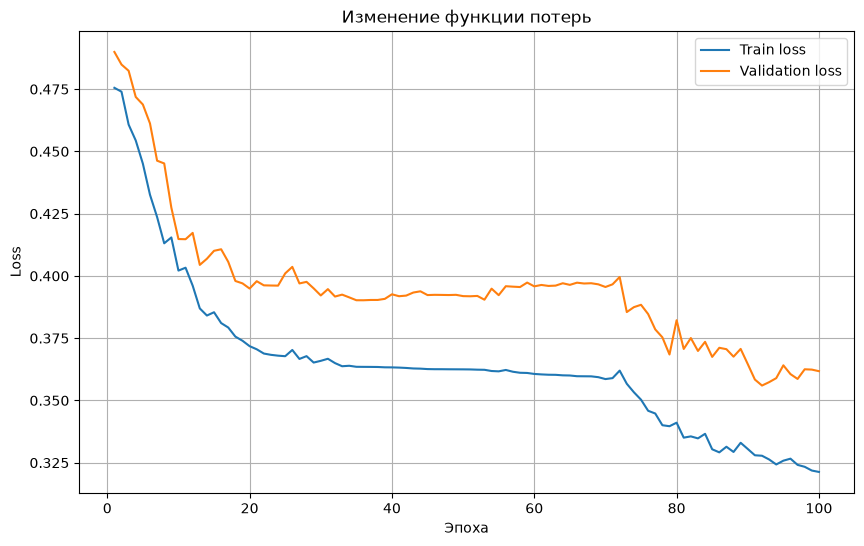

In [15]:
graphic()

In [16]:
net = Network([784, 70, 10], alpha=4.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])


MODEL_FILE = 'litters_model_alpha45.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10
Epoch 1: train loss = 0.500710, validation loss = 0.497924, accuracy = 56/400
Epoch 2: train loss = 0.482954, validation loss = 0.470066, accuracy = 60/400
Epoch 3: train loss = 0.474921, validation loss = 0.473656, accuracy = 67/400
Epoch 4: train loss = 0.468335, validation loss = 0.469853, accuracy = 67/400
Epoch 5: train loss = 0.468360, validation loss = 0.469555, accuracy = 71/400
Epoch 6: train loss = 0.471708, validation loss = 0.475703, accuracy = 68/400
Epoch 7: train loss = 0.463502, validation loss = 0.463259, accuracy = 80/400
Epoch 8: train loss = 0.460063, validation loss = 0.463551, accuracy = 74/400
Epoch 9: train loss = 0.460525, validation loss = 0.461306, accuracy = 74/400
Epoch 10: train loss = 0.459182, validation loss = 0.461087, accuracy = 70/400
Epoch 11: train loss = 0.458108, validation loss = 0.461393, accuracy = 67/400
Epoch 12

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

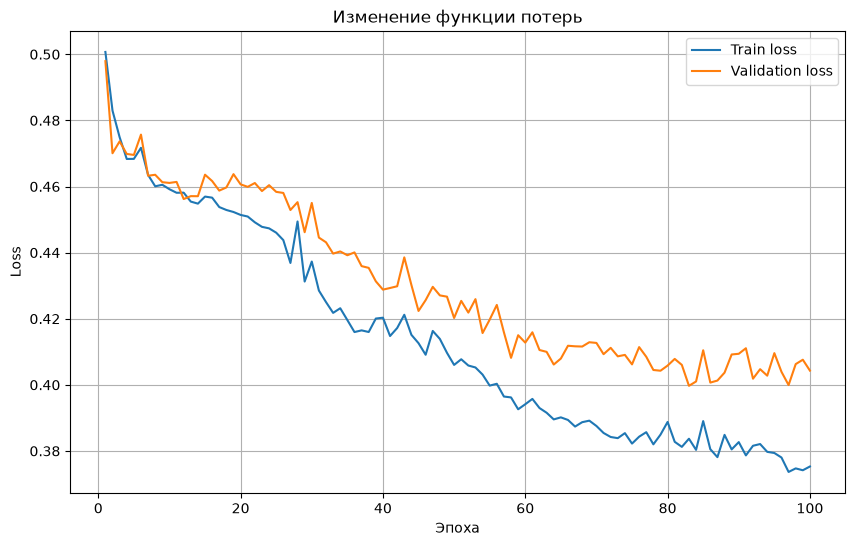

In [17]:
graphic()